In [14]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd
from glob import glob
import json


In [15]:
experiment_path = (
    "/Users/clairenastaskin/data/sub-Forest001/2026-01-20/ses-20260120/fusi/task-audio_run-004/GLM_processing/"
)

# Extract fUSI data and t_r
fusi_path = os.path.join(experiment_path, "sub-Forest001_ses-20260120_task-audio_run-004_pwd.nii.gz")
fusi_data = nib.load(fusi_path)
fusi_data = fusi_data.get_fdata()

t_r_path = os.path.join(experiment_path, "t_r.npy")
t_r = np.load(t_r_path)

# Extract time_stamps
task_path = glob(os.path.join(experiment_path, '*events.tsv'))[0]
task_events = pd.read_csv(task_path, sep='\t')

# Extract json info
info_file_path = glob(os.path.join(experiment_path, "*pwd.json"))[0]
# Read the json file
with open(info_file_path, 'r') as f:
    info = json.load(f)

frame_times = info['VolumeTiming']
frame_times = np.array(frame_times)

In [26]:
coords = (54,24,18) # Coordinate of the pixel of interest (with high z-score for example from freeview) from the non-realigned data 
radius = 2
timecourse = np.mean(fusi_data[coords[0]-radius:coords[0]+radius,coords[1]-radius:coords[1]+radius,coords[2]-radius:coords[2]+radius,:],axis=(0,1,2))
np.save(
    os.path.join(experiment_path, f"time_course_coord_{coords[0]}-{coords[1]}-{coords[2]}_radius{radius}.npy"),
    timecourse
)
print(timecourse.shape)

(1582,)


In [27]:
def boxcar_smooth(data, window_size):
    if window_size > 0:
        smoothed_data = np.copy(data)
        for t in range(data.shape[3]):
            start_index = max(0, t - window_size // 2)
            end_index = min(data.shape[3], t + window_size // 2 + 1)
            smoothed_data[:, :, :, t] = np.mean(
                data[:, :, :, start_index:end_index], axis=3
            )
    else:
        smoothed_data = data
    return smoothed_data


# Apply temporal smoothing with boxcar window
window_size = 3  # Number of time points to use for smoothing
timecourse = boxcar_smooth(timecourse[np.newaxis, np.newaxis, np.newaxis, :], window_size)[0,0,0,:]

In [28]:
# Detrend signal
from nilearn.signal import clean
# Reshape timecourse to 2D (nilearn expects shape: [n_timepoints, n_features])
timecourse_2d = timecourse[:, np.newaxis]  # Shape: (237, 1)
detrended_timecourse = clean(
    timecourse_2d,
    confounds=None,
    detrend=None,
    standardize=None,       
    low_pass=None,
    high_pass=0.01,
    t_r=t_r,
    ensure_finite=True,      # avoids NaN propagation
)
# Flatten back to 1D if needed
detrended_timecourse = detrended_timecourse.flatten()

In [29]:
power_doppler_time_course = pd.DataFrame(
    {
        "timestamp": frame_times,
        "power_doppler_value": detrended_timecourse,
    }
)

In [30]:
task_list_type = task_events.trial_type.unique()
print(task_list_type)


['Audio only' 'Speech']


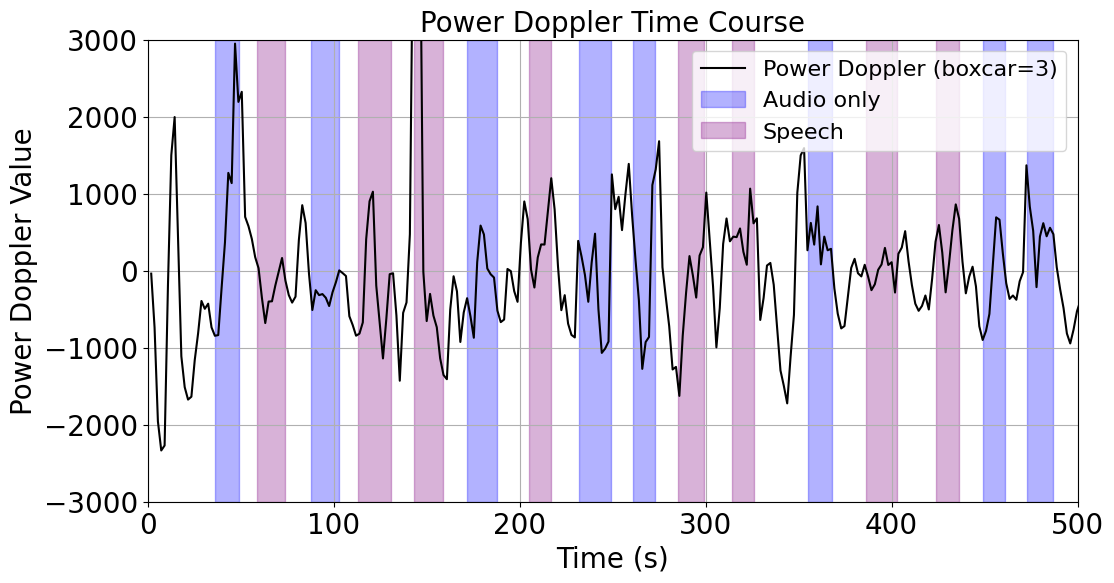

In [31]:
# Smooth the Power Doppler signal using a boxcar of width 2
signal = power_doppler_time_course.power_doppler_value; 

plt.figure(figsize=(12, 6))
plt.plot(
    power_doppler_time_course.timestamp,
    signal,
    color="black",
    label=f"Power Doppler (boxcar={window_size})"
)

task_colors = ['blue', 'purple', 'gray', 'lightgreen', 'red', 'orange', 'yellow', 'pink']

# Add colored rectangles for stimulus periods
for task_index in range(len(task_list_type)):
    task = task_list_type[task_index]
    task_events_timing = pd.DataFrame()
    task_events_timing["Event"] = ["start", "stop"] * len(
        task_events[task_events["trial_type"] == task]
    )
    task_events_timing["Timestamp"] = [
        onset
        for onset, duration in zip(
            task_events[task_events["trial_type"] == task]["onset"],
            task_events[task_events["trial_type"] == task]["duration"],
        )
        for _ in range(2)
    ]
    # No need to .values for pandas Series, just use .to_numpy() or direct array ops
    durations = task_events[task_events["trial_type"] == task]["duration"].to_numpy()
    task_events_timing.loc[task_events_timing["Event"] == "stop", "Timestamp"] += durations.repeat(1)
    task_events_timing = task_events_timing.sort_values("Timestamp").reset_index(drop=True)
    start_times = task_events_timing[task_events_timing["Event"] == "start"]["Timestamp"]
    stop_times = task_events_timing[task_events_timing["Event"] == "stop"]["Timestamp"]
    # Use .iloc for pandas Series, not numpy arrays
    for i, (start, stop) in enumerate(zip(start_times, stop_times)):
        plt.axvspan(start, stop, color=task_colors[task_index], alpha=0.3, label=task if i == 0 else "")

plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Power Doppler Value", fontsize=20)
plt.title("Power Doppler Time Course", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylim(-3000, 3000)
plt.xlim(0,500)
plt.grid(True)
plt.legend(fontsize=16)
plt.show()


In [32]:
# Filter for skateboard_thumb.js task events
thumb_events = task_events[task_events["trial_type"] == "skateboard_pinky.js"]
# thumb_events = thumb_events.iloc[1:]  # Skip the first event

# Time window around events (in seconds)
window_before = 5
window_after = 5

plt.figure(figsize=(8, 6))

# Collect all aligned signals for computing mean and std
aligned_signals = []
aligned_times = []

# Plot a curve for each skateboard_thumb.js event and collect signals
for idx, (onset, duration) in enumerate(zip(thumb_events["onset"], thumb_events["duration"])):
    # Define time window
    time_start = onset - window_before
    time_end = onset + duration + window_after
    
    # Find indices in the power_doppler_time_course that fall within this window
    mask = (power_doppler_time_course["timestamp"] >= time_start) & (power_doppler_time_course["timestamp"] <= time_end)
    subset = power_doppler_time_course[mask].copy()
    
    # Normalize time to be relative to task onset
    subset["relative_time"] = subset["timestamp"] - onset
    
    # Plot individual trials in blue with thin lines
    plt.plot(subset["relative_time"], subset["power_doppler_value"], 
             color='blue', linewidth=0.5, alpha=0.6)
    
    # Collect for mean/std computation
    aligned_signals.append(subset["power_doppler_value"].values)
    aligned_times.append(subset["relative_time"].values)

# Compute mean and std across all trials (align by truncating to minimum length)
min_len = min([len(s) for s in aligned_signals])
aligned_signals = np.stack([s[:min_len] for s in aligned_signals])
aligned_times_plot = aligned_times[0][:min_len]

mean_signal = aligned_signals.mean(axis=0)
std_signal = aligned_signals.std(axis=0)

# Plot mean signal
plt.plot(aligned_times_plot, mean_signal, color='blue', linewidth=2, 
         label=f'Mean (N={len(thumb_events)})')

# Plot std as shaded area
plt.fill_between(aligned_times_plot, mean_signal - std_signal, mean_signal + std_signal,
                 color='blue', alpha=0.2, label='± 1 std')

# Add vertical lines to mark task start and end
plt.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Task Start')
plt.axvline(x=thumb_events.iloc[0]["duration"], color='red', linestyle='--', linewidth=2, label='Task End')

plt.xlabel("Time relative to task onset (s)", fontsize=14)
plt.ylabel("Power Doppler Value", fontsize=14)
plt.ylim(-500, 900)
plt.title("Power Doppler Signal during pinky tasks", fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
plt.show()

ValueError: min() arg is an empty sequence

<Figure size 800x600 with 0 Axes>